In [1]:
import torch
import string
import torch.nn.functional as F

words=open("names.txt",'r').read().splitlines()
stoi = {c: i for i, c in enumerate(string.ascii_lowercase,start=1)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}

In [2]:
import random
block_size = 5
def build_dataset(words):
    X=[]
    Y=[]
    for w in words:
        context = block_size * [0]  
        for ch in w + ".":
            idx = stoi[ch]
            X.append(context)
            Y.append(idx)
            #print("".join(itos[i] for i in context),"-->",ch)
            context = context[1:]+ [idx]
            
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    return X,Y

n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)
random.seed(42)
random.shuffle(words)
Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xtest,Ytest = build_dataset(words[n2:])

print(len(Xtr), len(Xdev), len(Xtest))

182625 22655 22866


In [3]:
#重置网络
n_embd = 5
n_hidden = 200
C = torch.rand(27,n_embd)
W = torch.rand(n_embd * block_size,n_hidden)
#b = torch.rand(n_hidden)
W2 = torch.rand(n_hidden,27) * 0.01
b2 = torch.rand(27) * 0
hngain = torch.ones((1, n_hidden))
hnbias = torch.zeros((1, n_hidden))
hmeanrunning = torch.zeros((1, n_hidden))
hstdrunning =  torch.ones((1, n_hidden))

parameters = [C, W, b, W2, b2 ,hngain,hnbias]
for p in parameters:
    p.requires_grad = True

In [4]:
total_params = sum(p.numel() for p in parameters)
print(f"总参数量: {total_params}")

总参数量: 11162


In [5]:
stepi = []
lossi = []


In [6]:
max_steps = 50000
for i in range(max_steps):
    
    idxx = torch.randint(0,Xtr.shape[0],(32,))
    emb = C[Xtr[idxx]]
    h = emb.view(-1,n_embd*block_size) @ W #+ b

    hmean = h.mean(0, keepdim = True)
    hstd = h.std(0, keepdim = True)
    hnorm = hngain*((h - hmean) /hstd )+hnbias 
    with torch.no_grad():
        hmeanrunning = hmeanrunning*0.999+hmean*0.001
        hstdrunning = hstdrunning*0.999+hstd*0.001
    htanh = torch.tanh(hnorm)
    
    logit = htanh @ W2 + b2
    loss = F.cross_entropy(logit,Ytr[idxx])
    
    for p in parameters:
        p.grad = None
    
    loss.backward()

    if i<15000:
        lr = 0.1
    else:
        lr = 0.01
    for p in parameters:
        p.data += - lr * p.grad

    stepi.append(i+1)
    lossi.append(loss.item())  

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

print(loss.item())

      0/  50000: 3.2982
  10000/  50000: 2.2834
  20000/  50000: 2.0701
  30000/  50000: 2.4419
  40000/  50000: 2.0898
2.232130527496338


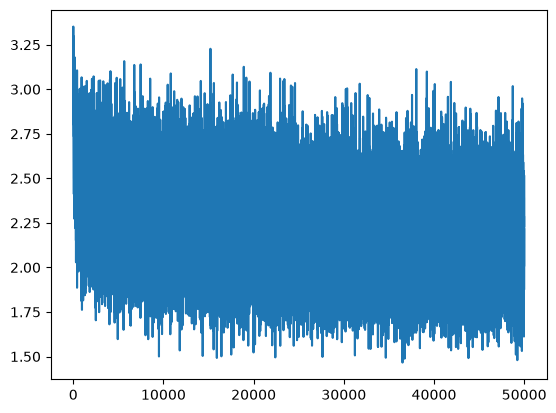

In [7]:
import matplotlib.pyplot as plt
plt.figure(1)
plt.plot(stepi,lossi)

In [8]:
with torch.no_grad():
    emb = C[Xtr]
    hnorm = (((emb.view(-1,25) @ W + b)-hmeanrunning)/hstdrunning)*hngain+hnbias
    h = torch.tanh(hnorm)
    logit = h @ W2 + b2
    loss = F.cross_entropy(logit,Ytr)
    print(f"loss_tr= {loss.item()}")

loss_tr= 2.1319425106048584


In [9]:
with torch.no_grad():
    emb1 = C[Xdev]
    hnorm = (((emb1.view(-1,25) @ W + b)-hmeanrunning)/hstdrunning)*hngain+hnbias
    h1 = torch.tanh(hnorm)
    logit1 = h1 @ W2 + b2
    loss1 = F.cross_entropy(logit1,Ydev)
    print(f"loss_dev= {loss1.item()}")

loss_dev= 2.1495490074157715


In [10]:
#使初始化后的loss不太大：（W2初始化为尽量小，b2初始化为0）
#loss_tr= 2.1336686611175537
#loss_dev= 2.1591925621032715

#加入batch归一化层
#loss_tr= 2.1319425106048584
#loss_dev= 2.1495490074157715

In [12]:
g = torch.Generator().manual_seed(42)

for _ in range(20):
    context = [0] * block_size
    out = []

    with torch.no_grad():
        for _ in range(30):  # 最多生成30个字符
            emb = C[torch.tensor([context])]
            hnorm = (((emb.view(-1,25) @ W + b)-hmeanrunning)/hstdrunning)*hngain+hnbias
            h = torch.tanh(hnorm)
            logits = h @ W2 + b2

            probs = F.softmax(logits, dim=1)
            idx = torch.multinomial(probs, 1, generator=g).item()

            if idx == 0:  # 生成结束符 '.'
                break

            out.append(itos[idx])
            context = context[1:] + [idx]

    print("".join(out))

yansyahle
amerillek
smang
jyanna
amdareen
enbell
amiiah
abkeles
lon
toya
savai
pupoltnnez
jeora
slay
shina
luncyan
kivie
aubreen
kidaum
lerei
